In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N_dim = 3
n_samples = 100000

def box_muller(n):
    m = int(np.ceil(n/2))
    U1 = np.clip(np.random.rand(m), 1e-10, 1.0)
    U2 = np.clip(np.random.rand(m), 1e-10, 1.0)
    Z1 = np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)
    Z2 = np.sqrt(-2*np.log(U1))*np.sin(2*np.pi*U2)
    return np.concatenate([Z1, Z2])[:n]

def compute_ecdf(data):
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, cdf




: 

In [38]:
# Step 5.1
X = np.zeros((N_dim, n_samples))
for i in range(N_dim):
    X[i, :] = box_muller(n_samples)


In [39]:
# Step 5.2
A = np.array([[2, 1, 0],[0, 1, 1],[1, 0, 2]], dtype=float)
b = np.array([1.0, 2.0, 3.0])
Y = A@X + b.reshape(-1, 1)

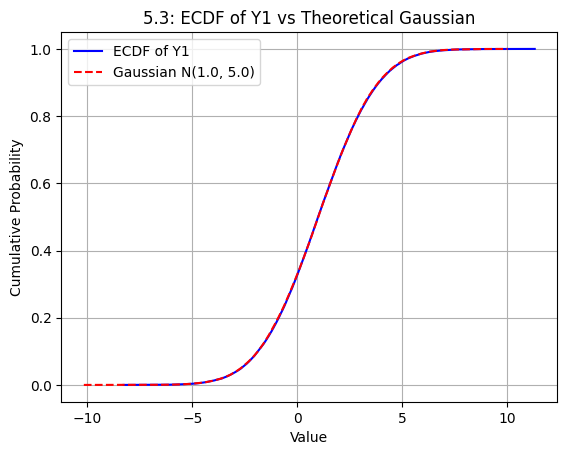

In [40]:
# Step 5.3
i_plot = 0
mu_X = np.mean(X, axis=1) 
mu_Y = A@mu_X + b
sigma2_Y = np.diag(A@A.T)

Yi_samples = Y[i_plot, :]
x_emp, cdf_emp = compute_ecdf(Yi_samples)

gauss_z= box_muller(n_samples)
gauss_samples = mu_Y[i_plot] + np.sqrt(sigma2_Y[i_plot])*gauss_z
x_th, cdf_th  = compute_ecdf(gauss_samples)

plt.plot(x_emp, cdf_emp, color='blue',label=f'ECDF of Y{i_plot+1}')
plt.plot(x_th,  cdf_th,  color='red', linestyle='--',label=f'Gaussian N({mu_Y[i_plot]:.1f}, {sigma2_Y[i_plot]:.1f})')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title(f'5.3: ECDF of Y{i_plot+1} vs Theoretical Gaussian')
plt.legend()
plt.grid(True)
plt.show()



In [42]:
# Step 5.4
K_emp    = np.cov(Y)
K_actual = A@A.T

print("Empirical covariance matrix:")
print(np.round(K_emp, 3))
print("\nActual covariance matrix:")
print(np.round(K_actual, 3))



Empirical covariance matrix:
[[5.034 1.003 1.998]
 [1.003 1.993 1.985]
 [1.998 1.985 4.988]]

Actual covariance matrix:
[[5. 1. 2.]
 [1. 2. 2.]
 [2. 2. 5.]]


n=10: MSE = 0.2104668942876762
n=100: MSE = 0.5511284952662283
n=1000: MSE = 0.03790990482298215
n=10000: MSE = 0.0007758569372827568
n=100000: MSE = 0.00027045915421673386
n=1000000: MSE = 1.8536467520832527e-05


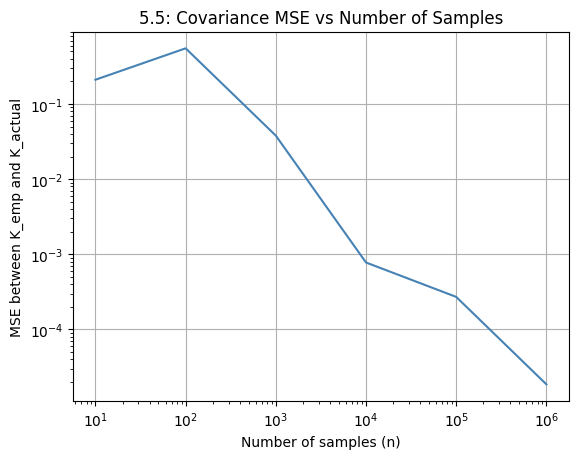

In [89]:
# Step 5.5
n_values = [10, 100, 1000, 10000, 100000, 1000000]
mse_list = []

for n in n_values:
    X_n = np.zeros((N_dim, n))
    for i in range(N_dim):
        X_n[i, :] = box_muller(n)
    Y_n =A@X_n + b.reshape(-1, 1)
    K_n= np.cov(Y_n)
    mse = np.mean((K_n - K_actual) ** 2)
    mse_list.append(mse)
    print(f"n={n}: MSE = {mse}")

plt.loglog(n_values, mse_list, color='steelblue')
plt.xlabel('Number of samples (n)')
plt.ylabel('MSE between K_emp and K_actual')
plt.title('5.5: Covariance MSE vs Number of Samples')
plt.grid(True)
plt.show()
